## Optimization of   first-generation antihistamines to design imroved (second-generation) agents.

### In this example we will attempt to optimize 1st generation antihistamine drugs: used in the past to manage allergies. The aim of optimization  is to reduce side effects: sleepiness, drowsiness, decreased attention; while keeping high anti-allergy activity. Modern antihistamines, e.g. cetirizine, loratadine etc. don't display these  side effects. This is thanks to lower blood-brain-barrier peneteration and higher receptor selectivity.
### Our aim  can be  achieved by simultaneously reducing blood-brain-barrier permeability  and keeping high *H1* histamine receptor activity. So, we will perform two-parameter optimization. (We will not optimize receptor selectivity in this example, as we would like to limit the number of parameters to two for simplicity.)

In [1]:
import os
from copy import copy
from optimizer import optimize
import process_config
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import pandas as pd
import sqlite3
import gzip, shutil

## 1. Let's read input settings from configuration file, which we prepared in advance


In [2]:
input_config = "examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/input_config.yaml"

## Please, download the database for fragment replacements form DropBox:
### (Note, download it to examples/ folder, because this is where the program will expect it to be, as specified in settings below)

https://www.dropbox.com/s/4r48ohopechsd59/replacements02_sa2.db.gz?dl=0

### read and uzip the archive:

In [ ]:
with gzip.open('examples/replacements02_sa2.db.gz', 'rb') as file_in:
    with open('examples/replacements02_sa2.db', 'wb') as file_out:
        shutil.copyfileobj(file_in, file_out)

In [3]:
settings = process_config.test_config(input_config)

In [4]:
settings

{'working_dir': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN',
 'num_output_compounds': 10,
 'seed_structure': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/decloxizine_seed.sdf',
 'number_of_selected_compounds': 10,
 'random_compounds_selection': 0.0,
 'descriptors_type': 'AP',
 'multitask': False,
 'bounded_box': True,
 'smart_string': '[!#1]!@!=!#[!#1]',
 'protected_ids': 'protected_ids',
 'max_cuts': 1,
 'radius': 2,
 'keep_stereo': False,
 'replacement_database': 'examples/replacements02_sa2.db',
 'number_of_worst_fragments': 6,
 'random_fragments_selection': 0.0,
 'min_inc': -2,
 'max_inc': 2,
 'max_frag_size': 7,
 'output_format': 'svm',
 'num_of_generation': 5,
 'n_cores': 10,
 'optimization_method': 'desirability',
 'store_all_files': True,
 'param_0': {'name': 231,
  'path': 'examples/models/231_spci_sklearn_atompairs_fp/',
  'types_of_alg': ['rf', 'gbm'],
  'type_of_model': 'reg',
  'threshold': 'more7.2',
  'range': 6.3,
  'desirability': '6:0,1

#### Some of  important settings are:
##### num_output_compounds: number of compounds with desired properties to be generated. The program will stop once this is satisfied (unless it will stop earlier upon satisfying another condition). 
##### number_of_selected_compounds: number of compounds selected for optimization in one generation. 
##### Larger  number will lead to: (1) more compounds in the final database of generated compounds (including both: optimal and non-optimal compounds); (2) longer overall running time; (3) lower  selection pressure at each generation. Smaller number will lead to opposite: (1) less compounds will be generated; (2) faster results; (3) selection pressure   at each generation  will be higher.
##### num_of_generation: maximum number of generations. Program will stop, once this is satisfied (unless stopped earlier upon another condition).
##### optimization_method: optimization method to use, i.e. desirability, or pareto (not both). 
##### protected_ids: field name in sdf file (with structure(s) to be optimized), which contains 0-based ids of atoms, that should not be affected by optimization. For instance, this could be an active scaffold which you  wish to retain.
#### For full description of all the settings, please, refer to README of the Crem_ml project.

In [5]:
# lets make a copy of settings dict to look at it later (optimizer will change some values in the original dict)
settings_copy = copy(settings)

### 2.  Let's look at our starting molecule to be optimized. This is a first generation antihistamine agent: decloxizine.  


In [6]:
sdf = Chem.SDMolSupplier(settings["seed_structure"])

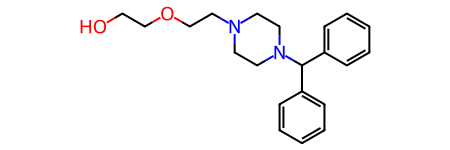

In [7]:
sdf[0]

## 3. Now, we can perform seed compound optimization

#### We will use settings, which we  have read from the config file. 


In [ ]:
optimize(settings=settings,
                   input_config=input_config,
                   brute_force=False,
                   number_generations=0) # this parameter is used only if brute_force, otherwise ignored and value from settings is used

__________________________________________________ 
Generation 0: 2023-09-20 10:50:07.888906
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started


/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator StandardScaler from version 0.22.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,
/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.22.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,
/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator RandomForestRegressor from versio

Prediction for logbb started


/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator RandomForestClassifier from version 0.22.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,
/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator DummyClassifier from version 0.22.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,
/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from vers

examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/out/generation_0/input_dataset_Hs.sdf
Processing predictions ...
['ID_0_0'] selected all compds
Finding fragments has started
Descriptors calculation started. Please wait it can take some time
Fragment contribution for 231 started


...

[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:39] WARNING: not removing hydrogen atom with

[10:50:46] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:46] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:46] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:46] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:49] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:49] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:49] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:49] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:49] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:50] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:50:50] WARNING: not removing hydrogen atom with dummy atom neighbors


__________________________________________________ 
Generation 2: 2023-09-20 10:51:13.153449
Descriptors calculation started. Please wait it can take some time


Process ForkPoolWorker-13:
Process ForkPoolWorker-2:
Process ForkPoolWorker-1:
Process ForkPoolWorker-14:
Process ForkPoolWorker-17:
Process ForkPoolWorker-12:
Process ForkPoolWorker-10:
Process ForkPoolWorker-20:
Process ForkPoolWorker-5:
Process ForkPoolWorker-7:
Process ForkPoolWorker-6:
Process ForkPoolWorker-3:
Process ForkPoolWorker-18:
Process ForkPoolWorker-8:
Process ForkPoolWorker-9:
Process ForkPoolWorker-4:
Process ForkPoolWorker-19:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
Tracebac

  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/multiprocessing/queues.py", line 352, in get
    res = self._reader.recv_bytes()
  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/multiprocessing/synchronize.py", line 96, in __enter__
    return self._semlock.__enter__()
  File "/home/maria/anaconda3/envs/crem_ml_py370/lib/python3.7/

### 4. Now  we can look at results
### in working directory we have a folder with the optimizer output: *out* 

In [12]:
settings_copy['working_dir']

'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN'

In [13]:
os.listdir(settings_copy['working_dir']+"/out")  # there are 3 generations, as we defined in settings

['generation_0', 'generation_1', 'generation_2']

In [14]:
os.listdir(settings_copy['working_dir'] + '/out//generation_2')  # let's look into the last generation

['input_dataset.sdf',
 'input_dataset_Hs.sdf',
 'output_match.sdf',
 'predictions_231.txt',
 'predictions_logbb.txt',
 'processed_predictions.sdf',
 'x.colnames',
 'x.rownames',
 'x.txt']

#### *output_match.sdf* is the file with compounds, having favorable  values of parameters (predicted).
#### Let' s look at them (in previous generations there might also be such compounds, but for now we will explore just last one)

In [15]:
sdf = Chem.SDMolSupplier("examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/out/generation_2/output_match.sdf")

In [16]:
mols = []
for mol in sdf:
    mols.append(mol)

In [17]:
for m in mols:
    AllChem.Compute2DCoords(m)

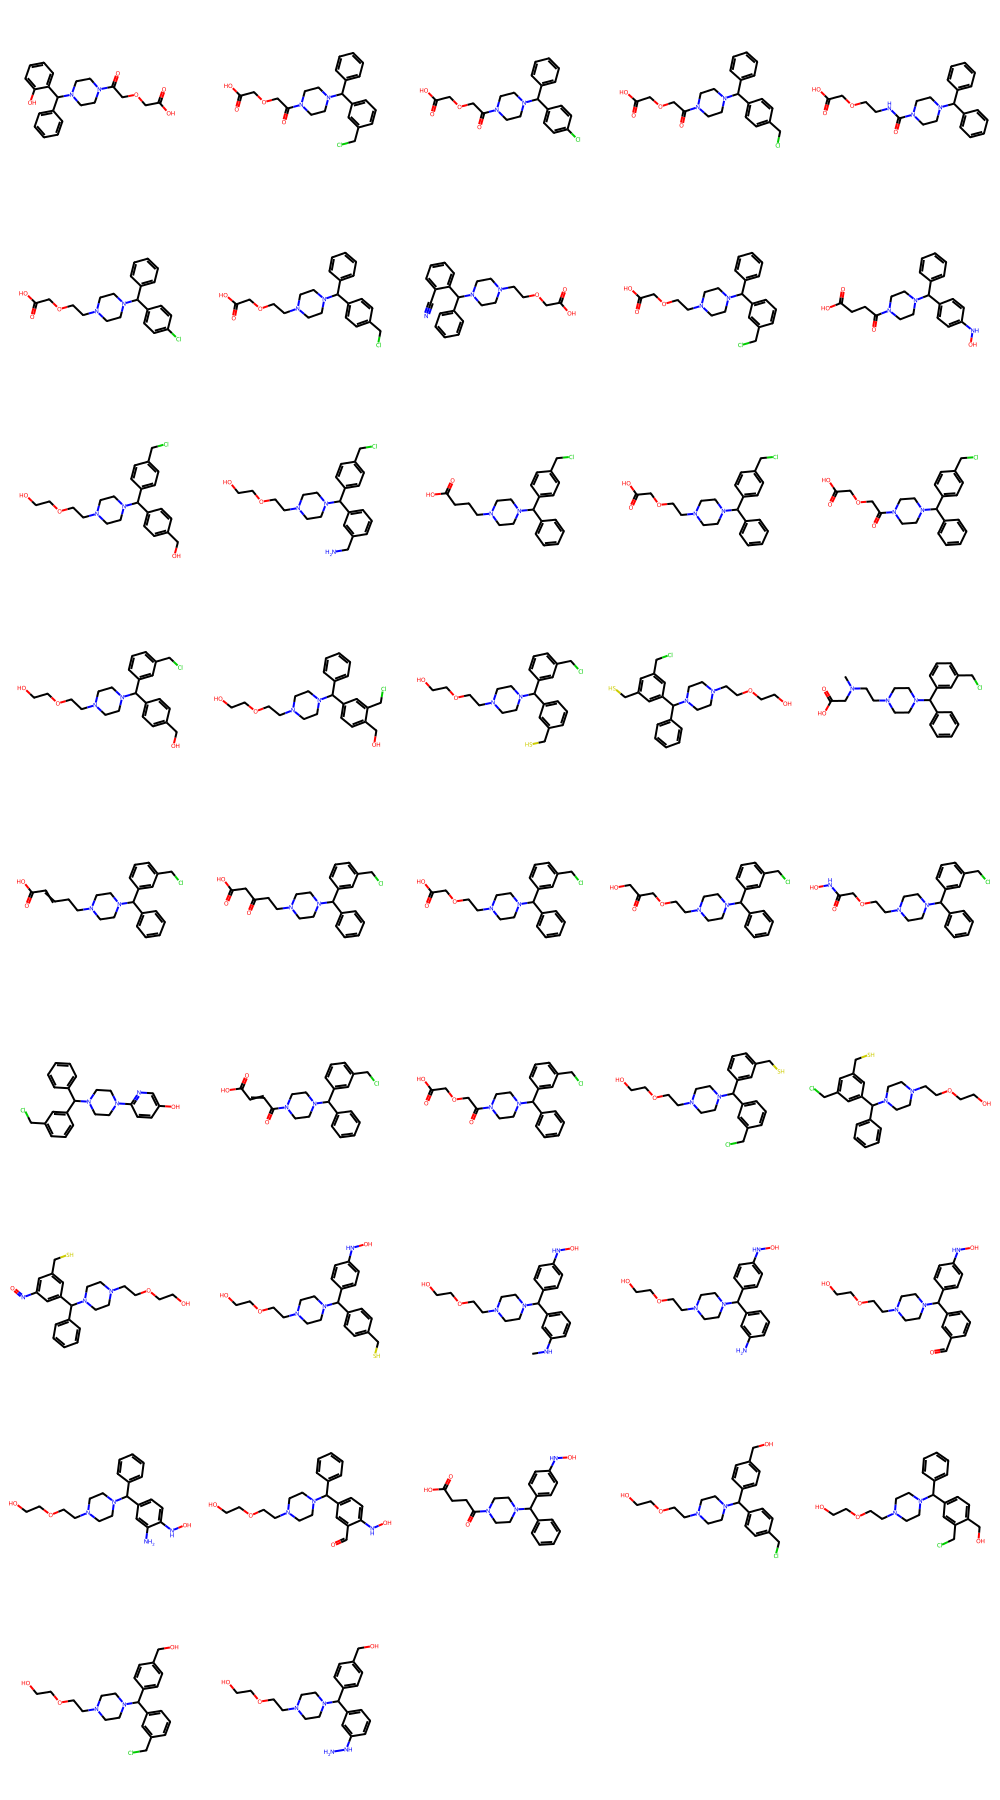

In [18]:
Draw.MolsToGridImage(mols, molsPerRow=5)

## We can recognize here a known antihistamine drug of 2nd generation in the results: cetirizine. 

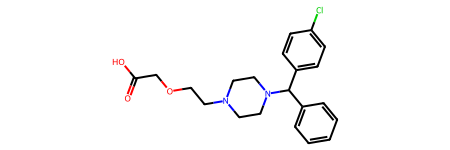

In [19]:
cetirizine = Chem.MolFromSmiles("OC(=O)COCCN1CCN(CC1)C(c1ccccc1)c1ccc(Cl)cc1")
cetirizine

## Let's find it in our sdf file.  We can run similarity search based on ECFP  fingerprints (RDKIT)

In [20]:
cetirizine_ecfp = AllChem.GetMorganFingerprintAsBitVect(cetirizine ,radius=3)

In [21]:
for mol in mols:
    if  DataStructs.FingerprintSimilarity(AllChem.GetMorganFingerprintAsBitVect(mol,radius=3), cetirizine_ecfp) == 1:
        print(mol.GetPropsAsDict())

{'parent_name': 'ID_1_182', 'transformation': '[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[Cl]-[c:6](:[c:4]:[*:2]):[c:5]:[*:3]', 'protected_ids': '1,2,3,4,5,7,9,10,11,13,14,15,16,17,20,23,25,27,32', 'ID': 'ID_2_163', 'pred_231': ' 7.428', 'pred_logbb': ' 0.269'}



#### Lets compare predictions of our models and true activity data for this molecule, taken from the ChEMBL database. 
####  As we can see, predicted values for  'ID_2_5314'  (cetirizine) H1 affinity is 7.42 (log units), and logBB is 0.269 (probability to cross BBB). True H1 activity is 8.2 and true ability to pass through BBB is low (class 0).
#### The predicted values for all generated molecules are in the properties dict above. They also can be found in the database file *output.db*, as well as in the pedictions_XXX.txt files for every generation (XXX is the name of parameter as in config.yaml).

## 5.  Conclusion:
### We could design cetirizine - a known 2nd generation antihistamine drug in 3 generations. As we can see, predicted values of affinity and logBB  are close to experimental data. This is a successsful result.

## 6. Now, let's perform the same task, but this time we will use *random compound selection*, to illustrate that the use of QSAR models in optimization really guides it to favorable compounds, while random selection may not work. 
### (Note, we will try fully random selection; however, in the case of partial randomness we  can get good results, see README.md)
 
#### We will use settings, which we  have read from the config file, but change "random_compound_selection" to 100%

In [23]:
settings_copy['random_compounds_selection'] = 1
# also, it's recommended to correct this value manually in the config.yaml after it is  saved by the program to working dir (for keeping track of experiments)

In [24]:
# let's  write results to a different folder
os.mkdir(settings_copy['working_dir'] + "_random_compounds")
settings_copy['working_dir'] = settings_copy['working_dir'] + "_random_compounds"
settings_copy['working_dir'] 

'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds'

In [25]:
settings_copy

{'working_dir': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds',
 'num_output_compounds': 10,
 'seed_structure': 'examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN/decloxizine_seed.sdf',
 'number_of_selected_compounds': 10,
 'random_compounds_selection': 1,
 'descriptors_type': 'AP',
 'multitask': False,
 'bounded_box': True,
 'smart_string': '[!#1]!@!=!#[!#1]',
 'protected_ids': 'protected_ids',
 'max_cuts': 1,
 'radius': 2,
 'keep_stereo': False,
 'replacement_database': 'examples/replacements02_sa2.db',
 'number_of_worst_fragments': 6,
 'random_fragments_selection': 0.0,
 'min_inc': -2,
 'max_inc': 2,
 'max_frag_size': 7,
 'output_format': 'svm',
 'num_of_generation': 5,
 'n_cores': 10,
 'optimization_method': 'desirability',
 'store_all_files': True,
 'param_0': {'name': 231,
  'path': 'examples/models/231_spci_sklearn_atompairs_fp/',
  'types_of_alg': ['rf', 'gbm'],
  'type_of_model': 'reg',
  'threshold': 'more7.2',
  'range': 6.3,
  'desira

In [26]:
optimize(settings=settings_copy,
                   input_config=input_config,
                   brute_force=False,
                   number_generations=0) # this parameter is used only if brute_force, otherwise ignored and value from settings is used

__________________________________________________ 
Generation 0: 2023-09-20 09:38:31.754692
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds/out/generation_0/input_dataset_Hs.sdf
Processing predictions ...
['ID_0_0'] selected all compds
10
Empty DataFrame
Columns: [231, logbb]
Index: [] pred_diff
Finding fragments has started
Descriptors calculation started. Please wait it can take some time
Fragment contribution for 231 started


/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Fragment contribution for logbb started
Processing contributions ...
Model                                                 231
Compound Frag_id Fragment                                
ID_0_0   11      OCCOCC[*]                      -0.083988
         12      c1ccc(C(c2ccccc2)[*])cc1        1.188701
         13      OCCOCCN1CCN([*])CC1             1.292736
         14      c1ccc([*])cc1                   1.529403
         15      OCCOCCN1CCN(C(c2ccccc2)[*])CC1  1.528468
Model                                               logbb
Compound Frag_id Fragment                                
ID_0_0   11      OCCOCC[*]                      -0.060773
         12      c1ccc(C(c2ccccc2)[*])cc1        0.348591
         13      OCCOCCN1CCN([*])CC1             0.109077
         14      c1ccc([*])cc1                   0.137563
         15      OCCOCCN1CCN(C(c2ccccc2)[*])CC1  0.121537
Model Compound  Frag_id                        Fragment       231     logbb
11      ID_0_0       11                    

RDKit WARNING: [09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
RDKit WARNING: [09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
[09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
[09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
[09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
[09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
[09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
[09:41:50] WARNING: not removing hydrogen atom with dummy atom neighbors
[09:41:50] WARNING: not removing h

__________________________________________________ 
Generation 1: 2023-09-20 09:41:53.472144
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds/out/generation_1/input_dataset_Hs.sdf
Processing predictions ...
Index(['ID_1_242', 'ID_1_7', 'ID_1_57', 'ID_1_214', 'ID_1_26', 'ID_1_239',
       'ID_1_74', 'ID_1_202', 'ID_1_55', 'ID_1_40'],
      dtype='object', name='id') best des
[] best des -random (check the 'head')
10
             231   logbb
id                      
ID_1_2    7.2355  0.8085
ID_1_3    7.7445  0.9060
ID_1_5    7.5085  0.7790
ID_1_6    7.4760  0.9640
ID_1_7    7.3540  0.6420
...          ...     ...
ID_1_242  7.1450  0.5530
ID_1_244  7.1685  0.8415
ID_1_245  7.4615  0.8895
ID_1_246  7.2760  0.8555
ID_1_247  7.1660  0.7760

[199 rows x 2 columns] pred_diff
10 n_random
['ID_1_209', 'ID_1_51', 'ID_1_44', 'ID_1_107', 'ID_1_177', '

...

__________________________________________________ 
Generation 2: 2023-09-20 09:45:56.988645
Descriptors calculation started. Please wait it can take some time
Prediction for 231 started
Prediction for logbb started
examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds/out/generation_2/input_dataset_Hs.sdf
Processing predictions ...


/home/maria/crem-ml/process_predictions.py:148: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  table['consensus']  = table.loc[:,['consensus' not in i for i in  table.columns]].mean(axis=1) # get new consensus


Index(['ID_2_2759', 'ID_2_2563', 'ID_2_2698', 'ID_2_2423', 'ID_2_2750',
       'ID_2_2376', 'ID_2_2351', 'ID_2_2363', 'ID_2_2511', 'ID_2_2535'],
      dtype='object', name='id') best des
[] best des -random (check the 'head')
10
              231   logbb
id                       
ID_2_10    7.2570  0.7375
ID_2_1000  7.3220  0.9115
ID_2_1002  7.2170  0.8335
ID_2_1003  7.2575  0.9360
ID_2_1004  7.3310  0.7430
...           ...     ...
ID_2_992   7.1975  0.7455
ID_2_993   6.9890  0.7605
ID_2_995   7.2385  0.8815
ID_2_996   7.2760  0.8590
ID_2_999   7.3130  0.8705

[2329 rows x 2 columns] pred_diff
10 n_random
['ID_2_1513', 'ID_2_275', 'ID_2_1461', 'ID_2_2090', 'ID_2_476', 'ID_2_1580', 'ID_2_961', 'ID_2_1697', 'ID_2_353', 'ID_2_773']
Optimizer reached number of fitted compounds specified in config.


SystemExit: 

/home/maria/anaconda3/envs/crem_ml/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [27]:
sdf = Chem.SDMolSupplier("examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds//out/generation_2/output_match.sdf")
mols = []
for mol in sdf:
    mols.append(mol)
for m in mols:
    AllChem.Compute2DCoords(m)

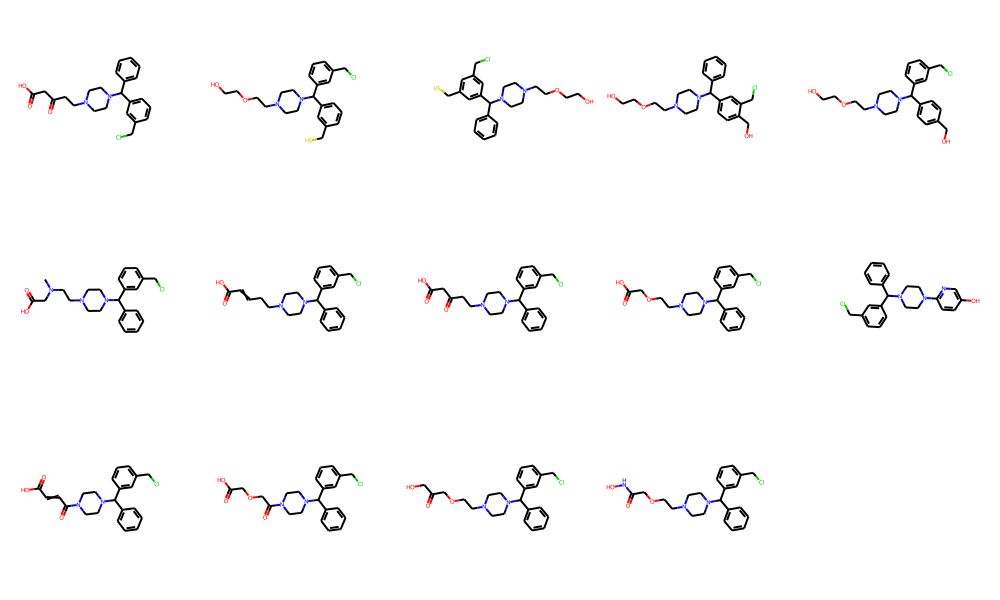

In [28]:
Draw.MolsToGridImage(mols, molsPerRow=5)

### It looks like we don't have cetirizine among the results. However, let's check the whole generated database. Main table of the database is called optimizer_table, and we will use sqlite python module to connect to it

In [29]:
con = sqlite3.connect("examples/antihistamine_drug_optimization_SPCI_SCIKIT_LEARN_random_compounds//output.db")

In [30]:
sql_query = """SELECT * FROM optimizer_table"""

In [31]:
df = pd.read_sql_query(sql_query,con)

In [32]:
df

,id,smi,generation,parent,transformation,fit,predicted_231,predicted_logbb
0,ID_0_0,OCCOCCN1CCN(C(c2ccccc2)c2ccccc2)CC1,0,None,None,0,7.2705,0.9095
1,ID_1_0,[H]OC([H])([H])C([H])([H])OC([H])([H])C([H])([...,1,ID_0_0,[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[B...,0,7.3270,0.9215
2,ID_1_1,[H]OC([H])([H])C([H])([H])OC([H])([H])C([H])([...,1,ID_0_0,[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[B...,0,7.2245,0.7560
3,ID_1_2,[H]OC([H])([H])C([H])([H])OC([H])([H])C([H])([...,1,ID_0_0,[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[C...,0,7.2355,0.8085
4,ID_1_3,[H]OC([H])([H])C([H])([H])OC([H])([H])C([H])([...,1,ID_0_0,[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[C...,0,7.7445,0.9060
...,...,...,...,...,...,...,...,...
3393,ID_2_3144,[H]ONC(=O)C([H])([H])OC([H])([H])C([H])([H])N1...,2,ID_1_38,[CH2](-[OH:4])-[CH2:5]-[O:6]-[!#1:3]>>[O]=[C](...,0,7.2125,0.7715
3394,ID_2_3145,[H]OC([H])(O)C([H])([H])OC([H])([H])C([H])([H]...,2,ID_1_38,[H]-[CH2:5](-[OH:3])-[CH2:4]-[!#1:1]>>[OH]-[C:...,0,7.5570,0.7570
3395,ID_2_3146,[H]OC([H])([H])C([H])(CC)OC([H])([H])C([H])([H...,2,ID_1_38,[H]-[CH2:6](-[CH2:4]-[!#1:1])-[O:5]-[!#1:2]>>[...,0,7.2110,0.7895
3396,ID_2_3147,[H]OC([H])([H])C([H])(OC)OC([H])([H])C([H])([H...,2,ID_1_38,[H]-[CH2:6](-[CH2:4]-[!#1:1])-[O:5]-[!#1:2]>>[...,0,7.4130,0.6845


In [33]:
# to quickly find cetirizine in this table, we can run similarity search based on ECFP  fingerprints from RDKIT

In [34]:
df["ecfp"] = df.smi.apply(lambda x: AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(x), radius=3))

In [35]:
df["ecfp_sim"] = df.ecfp.apply(lambda x: DataStructs.FingerprintSimilarity(x, cetirizine_ecfp))

### Let's sort our table from the most to the least similar to cetirizine.

In [36]:
df.sort_values("ecfp_sim", ascending=False)

,id,smi,generation,parent,transformation,fit,predicted_231,predicted_logbb,ecfp,ecfp_sim
215,ID_1_214,[H]OC(=O)COC([H])([H])C([H])([H])N1C([H])([H])...,1,ID_0_0,[CH2](-[CH2]-[OH:4])-[O]-[CH2:6]-[CH2:5]-[!#1:...,0,7.3485,0.6645,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.830508
915,ID_2_666,[H]OC(=O)C([H])([H])OC([H])([H])C([H])([H])N1C...,2,ID_1_209,[O]=[C](-[CH2:7]-[CH2:6]-[!#1:1])-[CH2:8]-[C:9...,0,7.3485,0.6645,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.830508
1818,ID_2_1569,[H]OC(=O)COC([H])([H])C([H])([H])N1C([H])([H])...,2,ID_1_44,[CH2](-[CH2]-[OH:4])-[O]-[CH2:6]-[CH2:5]-[!#1:...,0,7.2335,0.7130,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.761194
3355,ID_2_3106,[H]OC(=O)COC([H])([H])C([H])([H])N1C([H])([H])...,2,ID_1_38,[CH2](-[CH2]-[OH:4])-[O]-[CH2:6]-[CH2:5]-[!#1:...,0,7.4110,0.7400,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.750000
40,ID_1_39,[H]OC([H])([H])C([H])([H])OC([H])([H])C([H])([...,1,ID_0_0,[H]-[cH:6](:[cH:4]:[!#1:2]):[cH:5]:[!#1:3]>>[C...,0,7.5290,0.9355,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.731343
...,...,...,...,...,...,...,...,...,...,...
454,ID_2_205,[H]ON([H])C(=O)N([H])C([H])([H])C([H])([H])N1C...,2,ID_1_220,[H]-[CH2:6](-[CH2:5]-[!#1:1])-[N:7](-[!#1:3])-...,0,7.3135,0.7955,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.250000
2089,ID_2_1840,[H]OC([H])([H])C([H])([H])N([H])C(=O)C([H])([H...,2,ID_1_107,[H]-[CH2:6](-[CH2:5]-[!#1:1])-[N:7](-[!#1:3])-...,0,7.1585,0.8770,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.250000
2090,ID_2_1841,[H]OC([H])([H])C([H])([H])N([H])C(=O)C([H])([H...,2,ID_1_107,[H]-[CH2:6](-[CH2:5]-[!#1:1])-[N:7](-[!#1:3])-...,0,7.0675,0.8445,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.244898
1154,ID_2_905,[H]OC([H])([H])C([H])([H])N([H])C([H])([H])C([...,2,ID_1_177,[H]-[CH2:6](-[CH2:5]-[!#1:1])-[N:7](-[!#1:3])-...,0,7.3890,0.9145,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.239130


### There's no compound with 100% similarity to cetirizine, so  there is no cetirizine. This means it was helpful to perform QSAR guided compound selection versus random. 